# Diabetes Prediction using Machine Learning


## 0. Setup — Import Libraries

**Purpose:** Before we can do anything — load data, make plots, or train models — we need to import the Python libraries that provide those capabilities. Think of libraries as toolboxes: each one gives us a set of ready-made functions so we don't have to write everything from scratch.

Here is what each library does and *why* we need it:

| Library | What it does | Why we need it in this notebook |
|---|---|---|
| `numpy` | Fast numerical operations on arrays and matrices | Many ML computations happen on arrays; NumPy is the backbone |
| `pandas` | Tabular data structures (DataFrames) and manipulation | Loading our CSV, filtering rows, computing statistics |
| `matplotlib` | Low-level plotting library | Creating figures, axes, and customizing plot appearance |
| `seaborn` | High-level statistical plotting (built on matplotlib) | Beautiful histograms, bar charts, and heatmaps with minimal code |
| `scikit-learn` | Machine learning models, preprocessing, and evaluation | Training models, scaling features, computing accuracy/F1/ROC |

If you are running this in **Google Colab**, all these libraries are pre-installed, so the cell will run without errors.

In [ ]:
# --- Data handling -------------------------------------------------------
import numpy as np                    # Numerical operations (arrays, math)
import pandas as pd                   # DataFrames for tabular data

# --- Visualization -------------------------------------------------------
import matplotlib.pyplot as plt       # Core plotting engine
import seaborn as sns                 # Statistical plots on top of matplotlib

# --- Machine Learning (scikit-learn) -------------------------------------
from sklearn.model_selection import train_test_split      # Split data into train/test
from sklearn.preprocessing import StandardScaler          # Standardize numeric features
from sklearn.preprocessing import LabelEncoder            # Convert text labels -> numbers

# Five classifiers we will compare
from sklearn.linear_model import LogisticRegression       # Model 1
from sklearn.neighbors import KNeighborsClassifier        # Model 2
from sklearn.tree import DecisionTreeClassifier, plot_tree # Model 3 (+ tree visualization)
from sklearn.ensemble import RandomForestClassifier       # Model 4
from sklearn.svm import SVC                               # Model 5

# Evaluation metrics: each measures a different aspect of model performance
from sklearn.metrics import (
    accuracy_score,              # Overall correctness
    precision_score,             # Of predicted positives, how many are truly positive?
    recall_score,                # Of actual positives, how many did we catch?
    f1_score,                    # Harmonic mean of precision & recall
    confusion_matrix,            # 2x2 table of TP/TN/FP/FN
    ConfusionMatrixDisplay,      # Pretty-print the confusion matrix
    roc_curve,                   # FPR vs TPR at every threshold
    roc_auc_score,               # Area Under the ROC Curve
    classification_report        # Full precision/recall/F1 report
)

# --- Global settings -----------------------------------------------------
sns.set_style('whitegrid')                  # Clean grid background for all plots
plt.rcParams['figure.figsize'] = (7, 5)     # Default figure size (width, height) in inches

# Fixing the random seed ensures that every person running this notebook
# gets the exact same train/test split and the same model results.
RANDOM_STATE = 42

print('All libraries imported successfully!')

All libraries imported successfully!


## 1. Load the Dataset

**Purpose:** We need to read the CSV file into a pandas DataFrame so we can inspect and manipulate it. A DataFrame is essentially a table (rows x columns) stored in memory.

**How the cell below works:**
1. It first checks whether the file `diabetes_prediction_dataset.csv` already exists in the current directory.
2. **If it does NOT exist** (typical when you first open this notebook in Colab), it triggers the Colab file-upload widget so you can select the CSV from your computer.
3. **If the file already exists** (e.g., you re-run the cell), it skips the upload and loads directly.
4. `pd.read_csv()` reads the CSV into a DataFrame called `df`.
5. `df.head()` displays the first 5 rows so we can quickly verify the data looks correct.

In [ ]:
import os  # Provides functions to interact with the operating system

# Step 1: Check if the CSV file is already present
if not os.path.exists('diabetes_prediction_dataset.csv'):
    try:
        # google.colab.files is only available inside Google Colab
        from google.colab import files
        print("Please choose 'diabetes_prediction_dataset.csv' to upload:")
        uploaded = files.upload()          # Opens a file-picker dialog in the browser
    except ImportError:
        # If we're NOT in Colab and the file is missing, raise a helpful error
        raise FileNotFoundError(
            'diabetes_prediction_dataset.csv not found. '
            'Please place it in the working directory.'
        )

# Step 2: Read the CSV into a pandas DataFrame
df = pd.read_csv('diabetes_prediction_dataset.csv')

# Step 3: Quick sanity check
print('Dataset loaded successfully!')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

# Show the first 5 rows to visually confirm the data
df.head()

Dataset loaded successfully!
Shape: 100,000 rows x 9 columns


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## 2. Exploratory Data Analysis (EDA)

**Purpose:** Before building any model we must *understand* our data. Jumping straight to model training without exploration is a common beginner mistake - it can lead to garbage-in-garbage-out results.

In this section we will answer five key questions:

1. **What columns (features) do we have, and what types are they?** - Numeric features behave differently from categorical ones in ML algorithms.
2. **Are there any missing values?** - Missing data can crash some models or silently distort results.
3. **What do the basic statistics look like?** - Mean, min, max, and standard deviation tell us the scale and spread of each feature.
4. **How balanced is the target variable (`diabetes`)?** - A heavily imbalanced target means simple accuracy is misleading.
5. **How are the numeric features distributed, and how do they correlate with each other and with diabetes?** - This tells us which features are likely to be informative for prediction.

### Our Features at a Glance
| Column | Meaning | Type |
|---|---|---|
| `gender` | Male / Female / Other | Categorical |
| `age` | Age in years | Numeric (continuous) |
| `hypertension` | 0 = No, 1 = Yes | Binary |
| `heart_disease` | 0 = No, 1 = Yes | Binary |
| `smoking_history` | never / former / current / etc. | Categorical |
| `bmi` | Body Mass Index (weight in kg / height in m squared) | Numeric (continuous) |
| `HbA1c_level` | Average blood sugar over ~3 months (%) | Numeric (continuous) |
| `blood_glucose_level` | Blood sugar at time of test (mg/dL) | Numeric (continuous) |
| `diabetes` | **Target**: 0 = No diabetes, 1 = Diabetes | Binary |

### 2.1 Dataset Shape, Data Types & Missing Values

**Purpose of this cell:**
- `df.shape` tells us how many rows (patients) and columns (features) we have.
- `df.dtypes` shows the data type of each column - `object` means text (categorical), `int64`/`float64` means numeric.
- `df.isnull().sum()` counts missing values per column. If any column has missing values, we would need to decide how to handle them.
- `df.describe()` gives us the five-number summary (min, 25th percentile, median, 75th percentile, max) plus mean and standard deviation for every numeric column.

In [ ]:
# Number of rows and columns
print('Shape (rows, columns):', df.shape)

# Data type of each column: helps identify which are numeric vs categorical
print('\nColumn data types:')
print(df.dtypes)

# Count of missing (NaN) values in each column
print('\nMissing values per column:')
print(df.isnull().sum())

# Statistical summary for all numeric columns
print('\nStatistical summary of numeric columns:')
df.describe()

Shape (rows, columns): (100000, 9)

Column data types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing values per column:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Statistical summary of numeric columns:


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


### 2.2 Target Variable - Class Balance Check

**Purpose:** This is one of the most important EDA steps for classification. We need to know how many patients have diabetes (class 1) versus how many do not (class 0).

**Why this matters:**
- If 91.5% of patients do **not** have diabetes, a model that *always* predicts 'No diabetes' would score 91.5% accuracy - yet it would never catch a single diabetic patient!
- This situation is called **class imbalance**, and it is extremely common in medical datasets.
- Because of imbalance, we will rely on metrics beyond accuracy - particularly **Recall** (did we catch all diabetic patients?) and **F1-score** (a balanced combination of precision and recall).

The cell below prints the exact counts and percentages, and draws a bar chart so the imbalance is visually obvious.

Class counts:
 diabetes
0    91500
1     8500
Name: count, dtype: int64

Class percentages:
 diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64


/tmp/ipykernel_2737/875171086.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2737/875171086.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Diabetes (0)', 'Diabetes (1)'])  # Readable tick labels


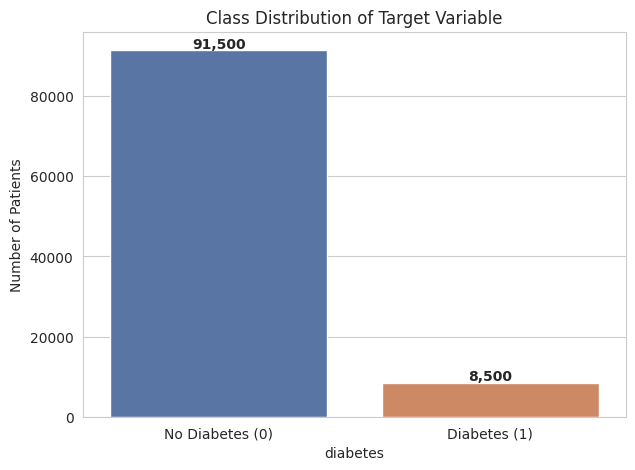

In [ ]:
# Count how many samples belong to each class (0 = No Diabetes, 1 = Diabetes)
counts = df['diabetes'].value_counts()

# Same thing as percentages (normalize=True gives proportions; x100 = %)
percentages = df['diabetes'].value_counts(normalize=True) * 100

print('Class counts:\n', counts)
print('\nClass percentages:\n', percentages.round(2))

# --- Bar chart of class distribution ---
fig, ax = plt.subplots()

sns.countplot(
    x='diabetes',                              # Column to count
    data=df,                                   # Source DataFrame
    palette=['#4C72B0', '#DD8452'],             # Blue for class 0, orange for class 1
    ax=ax                                      # Draw on our axes object
)

ax.set_xticklabels(['No Diabetes (0)', 'Diabetes (1)'])  # Readable tick labels
ax.set_title('Class Distribution of Target Variable')
ax.set_ylabel('Number of Patients')

# Annotate each bar with the exact count (placed slightly above the bar)
for i, v in enumerate(counts):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.show()

### 2.3 Distribution of Numeric Features by Diabetes Status

**Purpose:** We want to see how each numeric feature is distributed, and - crucially - whether the distribution looks *different* for diabetic vs. non-diabetic patients. If a feature has similar distributions in both groups, it probably won't help the model. If the distributions are clearly separated, that feature is likely a strong predictor.

**What to look for in each subplot:**
- **`age`:** Are diabetic patients generally older?
- **`bmi`:** Do diabetic patients tend to have higher BMI?
- **`HbA1c_level`:** HbA1c is a direct measure of long-term blood sugar control - we expect strong separation here.
- **`blood_glucose_level`:** A direct blood sugar reading - also expected to separate the groups well.

Each subplot overlays a histogram and a KDE (kernel density estimate) curve for both classes, making it easy to compare.

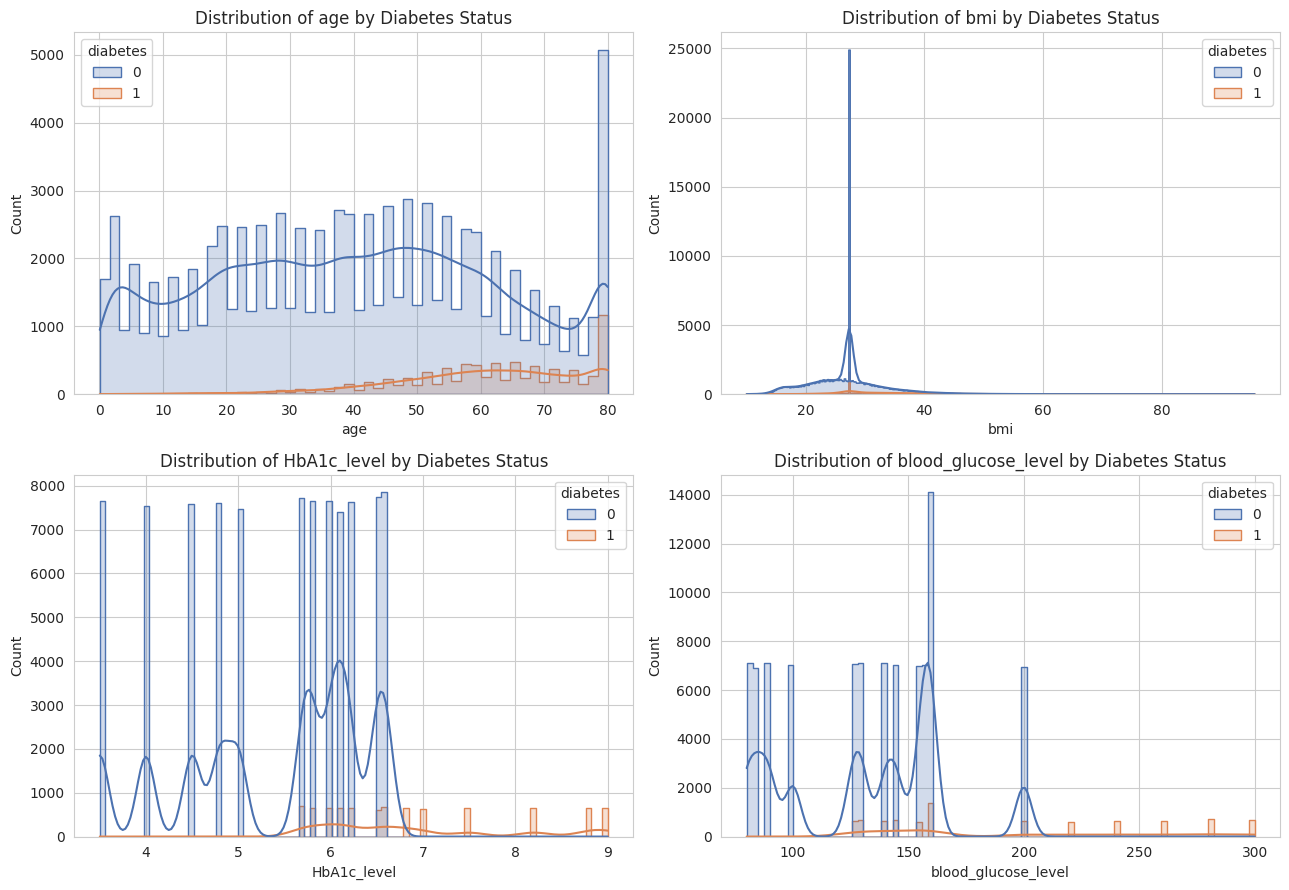

In [ ]:
# The four numeric features we want to visualize
numeric_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

# Create a 2x2 grid of subplots (one subplot per feature)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()  # Flatten 2D array of axes into 1D list for easy indexing

for i, col in enumerate(numeric_cols):
    sns.histplot(
        data=df,                                # Source DataFrame
        x=col,                                  # Which column to plot
        hue='diabetes',                         # Color by diabetes status (0 vs 1)
        kde=True,                               # Overlay a smooth density curve
        ax=axes[i],                             # Which subplot to draw on
        palette=['#4C72B0', '#DD8452'],          # Blue = no diabetes, Orange = diabetes
        element='step'                          # Step-style histogram (easier to compare)
    )
    axes[i].set_title(f'Distribution of {col} by Diabetes Status')

plt.tight_layout()  # Adjust spacing so titles/labels don't overlap
plt.show()

### 2.4 Correlation Heatmap

**Purpose:** The Pearson correlation coefficient $r$ measures the *strength and direction* of the **linear relationship** between two numeric variables. Values range from $-1$ (perfect negative) through $0$ (no linear relationship) to $+1$ (perfect positive).

$$
r_{X,Y} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}}
$$

**What to look for in the heatmap below:**
- **Bottom row (or rightmost column):** Shows each feature's correlation with the **target** (`diabetes`). Higher positive values = stronger predictors.
- **Feature-to-feature cells:** High correlation between *input* features (> 0.8) indicates **multicollinearity** - the features carry redundant information.
- **Expected:** `HbA1c_level` and `blood_glucose_level` should show the highest correlation with `diabetes`.

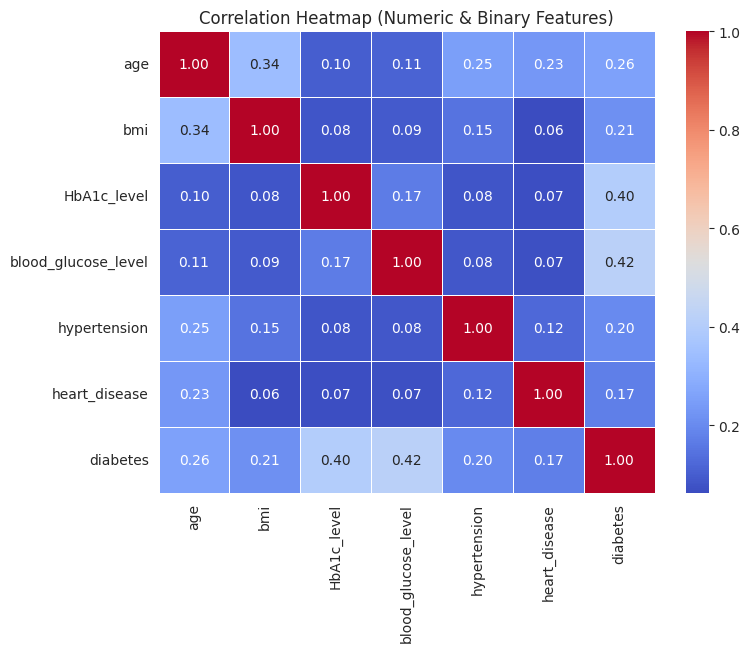

In [ ]:
plt.figure(figsize=(8, 6))

# Select only numeric/binary columns for correlation
corr_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level',
             'hypertension', 'heart_disease', 'diabetes']

# .corr() computes the pairwise Pearson correlation matrix
corr = df[corr_cols].corr()

# Draw the heatmap with annotations
sns.heatmap(
    corr,
    annot=True,       # Print the correlation value inside each cell
    cmap='coolwarm',   # Blue = negative, Red = positive
    fmt='.2f',         # Two decimal places
    linewidths=0.5     # Thin lines between cells for readability
)
plt.title('Correlation Heatmap (Numeric & Binary Features)')
plt.show()

## 3. Data Preprocessing

**Purpose:** Raw data almost never comes in a form that ML algorithms can use directly. We need to prepare it through three key steps:

1. **Encode categorical variables** - ML models work with numbers, not text. We must convert `gender` and `smoking_history` into numeric values.
2. **Split into train/test sets** - We hold out 20% of the data that the model *never sees during training*. This simulates how the model would perform on new patients.
3. **Scale (standardize) numeric features** - Some models (KNN, SVM, Logistic Regression) are sensitive to feature magnitude.

---

### 3.1 Encoding Categorical Variables

**Purpose:** The columns `gender` and `smoking_history` contain text values. We use **Label Encoding** to map each unique category to an integer:

$$
\text{Female} \rightarrow 0, \quad \text{Male} \rightarrow 1, \quad \text{Other} \rightarrow 2
$$

> **Note:** Label encoding implies an ordering (0 < 1 < 2) which may not be meaningful for categories like gender. For tree-based models this is fine, but for linear models, one-hot encoding is often preferred. We use label encoding here for simplicity.

In [ ]:
# Work on a copy so we preserve the original DataFrame for reference
df_encoded = df.copy()

# We'll store each fitted LabelEncoder so we can reuse it later
# (e.g., when encoding a new patient's data in the interactive tool)
label_encoders = {}

categorical_cols = ['gender', 'smoking_history']

for col in categorical_cols:
    le = LabelEncoder()                               # Create a fresh encoder
    df_encoded[col] = le.fit_transform(df_encoded[col])  # Learn mapping & transform
    label_encoders[col] = le                           # Save the encoder for future use
    print(label_encoders)

    # Print the mapping so we can verify it makes sense
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'{col} mapping: {mapping}')

# Show the first few rows of the encoded DataFrame to confirm text -> numbers
df_encoded.head()

{'gender': LabelEncoder()}
gender mapping: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
{'gender': LabelEncoder(), 'smoking_history': LabelEncoder()}
smoking_history mapping: {'No Info': np.int64(0), 'current': np.int64(1), 'ever': np.int64(2), 'former': np.int64(3), 'never': np.int64(4), 'not current': np.int64(5)}


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0


### 3.2 Feature-Target Split, then Train-Test Split

**Purpose:** Two splits happen here:

**Split 1 - Features (X) vs. Target (y):**
- `X` = all input columns the model uses to make predictions (everything *except* `diabetes`)
- `y` = the target column (`diabetes`) - the thing we want to predict

**Split 2 - Training set vs. Test set:**
- **Training set (80%):** The model *learns* from this data.
- **Test set (20%):** The model *never* sees this during training. We evaluate it here to estimate real-world performance.

**Key parameter - `stratify=y`:** This ensures both splits preserve the same class ratio (~91.5% / ~8.5%). Without this, random chance could unevenly represent the small diabetes class.

In [ ]:
# Split 1: Separate features (X) from target (y)
X = df_encoded.drop('diabetes', axis=1)  # All columns except 'diabetes'
y = df_encoded['diabetes']                # Just the 'diabetes' column

# Split 2: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,                # 20% of data reserved for testing
    random_state=RANDOM_STATE,     # Fixed seed for reproducibility
    stratify=y                     # Preserve class proportions in both splits
)

print(f'Training set size: {X_train.shape[0]:,} samples x {X_train.shape[1]} features')
print(f'Test set size:     {X_test.shape[0]:,} samples x {X_test.shape[1]} features')
print(f'\nFeature columns: {list(X.columns)}')

# Verify stratification worked
print(f'\nDiabetes % in full data:     {y.mean()*100:.2f}%')
print(f'Diabetes % in training set:  {y_train.mean()*100:.2f}%')
print(f'Diabetes % in test set:      {y_test.mean()*100:.2f}%')

Training set size: 80,000 samples x 8 features
Test set size:     20,000 samples x 8 features

Feature columns: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']

Diabetes % in full data:     8.50%
Diabetes % in training set:  8.50%
Diabetes % in test set:      8.50%


### 3.3 Feature Scaling (Standardization)

**Purpose:** Some ML algorithms (Logistic Regression, KNN, SVM) compute distances or use gradient-based optimization. If one feature ranges 0-300 while another ranges 0-1, the large-range feature dominates.

**Solution - Z-score standardization:** Transform each feature so it has **mean = 0** and **std = 1**:

$$
z = \frac{x - \mu}{\sigma}
$$

where $\mu$ and $\sigma$ are computed **from the training set only**.

> **Critical rule:** We `fit` the scaler on **training data only**, then `transform` both train and test using those *same* parameters. If we fit on the full dataset, information from the test set 'leaks' into training (**data leakage**).

> **Note:** Tree-based models (Decision Tree, Random Forest) are not affected by feature scale because they use threshold comparisons, which are scale-invariant.

In [ ]:
scaler = StandardScaler()

# fit_transform on TRAINING data: learns mean & std, then applies transformation
X_train_scaled = scaler.fit_transform(X_train)

# transform on TEST data: uses the SAME mean & std from training (no re-fitting!)
X_test_scaled = scaler.transform(X_test)

# Wrap scaled arrays back into DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

# Show a before/after comparison for a single sample
print("Example: 'age' BEFORE scaling ->", X_train['age'].iloc[0])
print("Example: 'age' AFTER  scaling ->", round(X_train_scaled['age'].iloc[0], 3))
print()
print('After scaling, every column has mean ~ 0 and std ~ 1:')
print(X_train_scaled.describe().loc[['mean', 'std']].round(3))

Example: 'age' BEFORE scaling -> 80.0
Example: 'age' AFTER  scaling -> 1.691

After scaling, every column has mean ~ 0 and std ~ 1:
      gender  age  hypertension  heart_disease  smoking_history  bmi  \
mean    -0.0 -0.0          -0.0            0.0              0.0  0.0   
std      1.0  1.0           1.0            1.0              1.0  1.0   

      HbA1c_level  blood_glucose_level  
mean          0.0                 -0.0  
std           1.0                  1.0  


In [ ]:
X_train

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
74736,0,80.0,1,0,3,27.32,6.5,145
36589,0,19.0,0,0,4,25.18,4.5,126
37414,0,36.0,0,0,0,25.95,6.6,200
71251,0,35.0,0,0,1,23.43,6.0,159
40454,0,30.0,0,0,0,22.62,5.0,90
...,...,...,...,...,...,...,...,...
17083,0,39.0,0,0,4,32.28,4.8,130
27250,1,43.0,0,0,4,27.32,6.2,158
33409,0,52.0,1,0,3,27.32,5.8,155
91639,0,5.0,0,0,0,15.68,6.2,155


In [ ]:
X_train_scaled

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
74736,-0.841697,1.691070,3.516004,-0.202792,0.432427,0.000472,0.908249,0.170207
36589,-0.841697,-1.016460,-0.284414,-0.202792,0.961705,-0.321772,-0.959680,-0.297058
37414,-0.841697,-0.261902,-0.284414,-0.202792,-1.155408,-0.205824,1.001645,1.522815
71251,-0.841697,-0.306288,-0.284414,-0.202792,-0.626129,-0.585289,0.441267,0.514507
40454,-0.841697,-0.528217,-0.284414,-0.202792,-1.155408,-0.707259,-0.492698,-1.182401
...,...,...,...,...,...,...,...,...
17083,-0.841697,-0.128745,-0.284414,-0.202792,0.961705,0.747355,-0.679491,-0.198686
27250,1.186122,0.048798,-0.284414,-0.202792,0.961705,0.000472,0.628060,0.489914
33409,-0.841697,0.448269,3.516004,-0.202792,0.432427,0.000472,0.254474,0.416136
91639,-0.841697,-1.637860,-0.284414,-0.202792,-1.155408,-1.752293,0.628060,0.416136


## 4. Building 5 Classification Models

**Purpose:** We will now train **five fundamentally different classifiers** on the same data and compare their performance. Each algorithm 'thinks' about the problem in a different way.

For each model we will:
1. Explain the **core idea and math** (in a markdown cell)
2. **Train** the model on the training set
3. **Evaluate** it on the test set using our helper function

---

### Helper: `evaluate_model()` - A Reusable Evaluation Function

**Purpose:** Instead of copy-pasting evaluation code five times, we define one function that:
- Computes accuracy, precision, recall, F1-score, and ROC-AUC
- Plots the confusion matrix and ROC curve
- Returns a dictionary of results for later comparison

This follows the **DRY** (Don't Repeat Yourself) principle.

In [ ]:
# Dictionaries to collect results from all five models
trained_models = {}      # model_name -> fitted model object
predictions = {}         # model_name -> predicted labels (0 or 1) on X_test
pred_probabilities = {}  # model_name -> predicted probability of class 1 (for ROC)


def evaluate_model(name, model, X_te, y_te, y_pred, y_prob=None):
    '''Prints key classification metrics and plots confusion matrix + ROC curve.
    Returns a dict of results for the comparison table.'''

    # Compute metrics
    acc  = accuracy_score(y_te, y_pred)                           # Overall correctness
    prec = precision_score(y_te, y_pred, zero_division=0)         # Precision for class 1
    rec  = recall_score(y_te, y_pred, zero_division=0)            # Recall for class 1
    f1   = f1_score(y_te, y_pred, zero_division=0)                # Harmonic mean

    print(f'===== {name} =====')
    print(f'Accuracy  : {acc:.4f}')
    print(f'Precision : {prec:.4f}')
    print(f'Recall    : {rec:.4f}')
    print(f'F1-score  : {f1:.4f}')

    auc = np.nan  # Default if probabilities not available
    if y_prob is not None:
        auc = roc_auc_score(y_te, y_prob)
        print(f'ROC-AUC   : {auc:.4f}')

    # --- Visualization: Confusion Matrix + ROC Curve ---
    num_plots = 2 if y_prob is not None else 1
    fig, axes = plt.subplots(1, num_plots, figsize=(11, 4.5))
    if y_prob is None:
        axes = [axes]  # Make it a list so indexing works the same way

    # Confusion Matrix
    cm = confusion_matrix(y_te, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Diabetes', 'Diabetes']).plot(
        ax=axes[0], cmap='Blues', colorbar=False
    )
    axes[0].set_title(f'{name}\nConfusion Matrix')

    # ROC Curve (only if probability estimates are available)
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_te, y_prob)       # FPR & TPR at every threshold
        axes[1].plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='darkorange')
        axes[1].plot([0, 1], [0, 1], linestyle='--', color='grey')  # Random baseline
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title(f'{name}\nROC Curve')
        axes[1].legend()

    plt.tight_layout()
    plt.show()

    return {'Model': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1-score': f1, 'ROC-AUC': auc}


# This list will collect the results dict from each model
results_list = []

### 4.1 Model 1 - Logistic Regression

Despite its name, Logistic Regression is a **classification** algorithm. Here is the core idea:

**Step 1 - Linear combination:** Compute a weighted sum of the input features:
$$
z = w_1x_1 + w_2x_2 + \dots + w_nx_n + b = \mathbf{w}^T\mathbf{x} + b
$$

**Step 2 - Sigmoid squashing:** Pass $z$ through the **sigmoid function** to convert it into a probability between 0 and 1:
$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

**Step 3 - Decision rule:** Predict class 1 (diabetes) if $\sigma(z) \geq 0.5$, else class 0.

**Training** finds the weights $\mathbf{w}$ and bias $b$ that minimize the **log-loss (binary cross-entropy)**:

$$
J(\mathbf{w}, b) = -\frac{1}{n}\sum_{i=1}^{n}\Big[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\Big]
$$

This loss is minimized via **gradient descent**.

**Why we use scaled data:** Gradient descent converges faster when all features are on the same scale.

In [ ]:
# Create and train the model
log_reg = LogisticRegression(
    random_state=RANDOM_STATE,  # Reproducibility
    max_iter=1000               # Max gradient descent iterations (default 100 may not converge)
)
log_reg.fit(X_train_scaled, y_train)  # Train on SCALED features

# Generate predictions on the test set
y_pred_lr = log_reg.predict(X_test_scaled)              # Hard predictions: 0 or 1
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]  # Probability of class 1 (diabetes)
# Note: predict_proba returns [P(class 0), P(class 1)]; we take column index 1

# Store for later comparison
trained_models['Logistic Regression'] = log_reg
predictions['Logistic Regression'] = y_pred_lr
pred_probabilities['Logistic Regression'] = y_prob_lr

# Evaluate
results_list.append(
    evaluate_model('Logistic Regression', log_reg, X_test_scaled, y_test, y_pred_lr, y_prob_lr)
)

### 4.2 Model 2 - K-Nearest Neighbors (KNN)

KNN is one of the simplest ML algorithms. The idea: **'tell me who your neighbors are, and I'll tell you who you are.'**

**How it works (at prediction time):**
1. Take a new patient's feature vector.
2. Compute the **Euclidean distance** to *every* training sample:
$$
d(\mathbf{p}, \mathbf{q}) = \sqrt{\sum_{i=1}^{n}(p_i - q_i)^2}
$$
3. Find the $K$ closest training samples (the 'neighbors').
4. Take a **majority vote** among the neighbors' labels.

**Key observations:**
- KNN has **no real training phase** - it stores the training data and does all work at prediction time.
- **Feature scaling is essential.** Without it, features with large ranges dominate the distance calculation.
- Choice of $K$ matters: too small = noisy, too large = over-smoothing. We use $K = 5$.

In [ ]:
# Create and train the model
knn = KNeighborsClassifier(
    n_neighbors=5  # Use the 5 closest training samples for each prediction
)
knn.fit(X_train_scaled, y_train)  # 'Training' = storing the scaled training data

# Generate predictions on the test set
y_pred_knn = knn.predict(X_test_scaled)              # Majority vote among 5 neighbors
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]  # Fraction of neighbors in class 1

# Store for later comparison
trained_models['KNN'] = knn
predictions['KNN'] = y_pred_knn
pred_probabilities['KNN'] = y_prob_knn

# Evaluate
results_list.append(
    evaluate_model('KNN (k=5)', knn, X_test_scaled, y_test, y_pred_knn, y_prob_knn)
)

### 4.3 Model 3 - Decision Tree

A Decision Tree learns a sequence of **if-then rules** that split the data into progressively purer groups.

**How splits are chosen - Gini Impurity:**

$$
Gini = 1 - \sum_{i=1}^{C} p_i^2
$$

where $p_i$ is the proportion of class $i$ samples in the node, and $C$ is the number of classes.

- $Gini = 0$ means the node is **pure** (all one class)
- $Gini = 0.5$ means **maximum impurity** for 2 classes (50/50 mix)

**Why we limit `max_depth`:** Without a limit, the tree memorizes the training data (**overfitting**). Setting `max_depth=6` forces generalization.

**Scaling not needed:** Trees only compare 'is feature > threshold?' - multiplying a feature by 1000 doesn't change which side of a threshold a value falls on.

In [ ]:
# Create and train the model
dt = DecisionTreeClassifier(
    max_depth=6,                  # Limit depth to prevent overfitting
    random_state=RANDOM_STATE     # Reproducibility
)
dt.fit(X_train, y_train)  # Tree-based models do NOT need scaled features

# Generate predictions on the test set
y_pred_dt = dt.predict(X_test)              # Follow the learned if-then rules
y_prob_dt = dt.predict_proba(X_test)[:, 1]  # Proportion of class-1 in the leaf node

# Store for later comparison
trained_models['Decision Tree'] = dt
predictions['Decision Tree'] = y_pred_dt
pred_probabilities['Decision Tree'] = y_prob_dt

# Evaluate
results_list.append(
    evaluate_model('Decision Tree', dt, X_test, y_test, y_pred_dt, y_prob_dt)
)

#### Visualizing the Decision Tree

**Purpose:** One of the biggest advantages of decision trees is **interpretability** - we can literally see the rules the model learned. The cell below draws the top 2 levels, showing the feature and threshold at each split, the Gini impurity, sample count, and majority class.

In [ ]:
plt.figure(figsize=(20, 8))

plot_tree(
    dt,
    max_depth=2,                                         # Only show top 2 levels
    feature_names=X.columns,                             # Label splits with feature names
    class_names=['No Diabetes', 'Diabetes'],             # Label leaves with class names
    filled=True,                                         # Color nodes by majority class
    fontsize=10
)
plt.title('Decision Tree - Top 2 Levels (Simplified View)')
plt.show()

#### Feature Importance (Decision Tree)

**Purpose:** After training, scikit-learn reports how much each feature contributed to reducing impurity across all splits. Features used in early splits with large impurity reductions get higher importance scores. This helps explain the model's reasoning.

In [ ]:
# feature_importances_ is an array of scores (one per feature) that sum to 1.0
importances = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Decision Tree - Feature Importance')
plt.xlabel('Importance Score (sums to 1.0)')
plt.show()

# Print exact values for reference
print('Feature importances (sorted):')
print(importances.round(4).to_string())

### 4.4 Model 4 - Random Forest

A single Decision Tree can overfit. A **Random Forest** fixes this using **Bagging (Bootstrap Aggregating)**:

1. Create $T$ **bootstrap samples** (random samples with replacement) from the training data.
2. Train one Decision Tree per sample. At each split, only a **random subset of features** is considered.
3. Aggregate predictions via **majority vote**:
$$
\hat{y} = \text{mode}\{T_1(\mathbf{x}), T_2(\mathbf{x}), \dots, T_n(\mathbf{x})\}
$$

**Why this works:** Each tree makes slightly different errors (trained on different data/features). Averaging cancels out random errors, producing a more stable, accurate predictor.

**Key hyperparameters:**
- `n_estimators=200` - 200 trees in the forest
- `max_depth=10` - limits each tree's depth
- `n_jobs=-1` - use all CPU cores for parallel training

In [ ]:
# Create and train the model
rf = RandomForestClassifier(
    n_estimators=200,             # Number of trees in the forest
    max_depth=10,                 # Max depth per tree
    random_state=RANDOM_STATE,    # Reproducibility
    n_jobs=-1                     # Use all CPU cores for faster training
)
rf.fit(X_train, y_train)  # No scaling needed (tree-based model)

# Generate predictions on the test set
y_pred_rf = rf.predict(X_test)              # Majority vote across 200 trees
y_prob_rf = rf.predict_proba(X_test)[:, 1]  # Average probability across all trees

# Store for later comparison
trained_models['Random Forest'] = rf
predictions['Random Forest'] = y_pred_rf
pred_probabilities['Random Forest'] = y_prob_rf

# Evaluate
results_list.append(
    evaluate_model('Random Forest', rf, X_test, y_test, y_pred_rf, y_prob_rf)
)

#### Feature Importance (Random Forest)

**Purpose:** Like a single Decision Tree, a Random Forest reports feature importance - but **averaged across all 200 trees**, making it a more robust estimate.

In [ ]:
# Average feature importance across all 200 trees
importances_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances_rf.values, y=importances_rf.index, palette='mako')
plt.title('Random Forest - Feature Importance (averaged over 200 trees)')
plt.xlabel('Importance Score (sums to 1.0)')
plt.show()

### 4.5 Model 5 - Support Vector Machine (SVM)

An SVM finds the **hyperplane** that separates the two classes with the **widest possible margin**.

**Linear SVM decision boundary:**
$$
\mathbf{w}^T\mathbf{x} + b = 0
$$

The nearest points to this boundary are called **support vectors**. SVM maximizes the margin by solving:
$$
\min_{\mathbf{w}, b} \ \frac{1}{2}\|\mathbf{w}\|^2 \quad \text{subject to} \quad y_i(\mathbf{w}^T\mathbf{x}_i + b) \geq 1 \ \ \forall i
$$

**The Kernel Trick:** The **RBF kernel** maps data into a higher-dimensional space where a linear separator exists:
$$
K(\mathbf{x}_i, \mathbf{x}_j) = \exp\left(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2\right)
$$

> **Performance note:** SVM training is $O(n^2)$ to $O(n^3)$, so on 80,000 samples it is very slow. We train on a **stratified subsample of 10,000** but evaluate on the **full test set** for a fair comparison.

In [ ]:
# Subsample training data for faster SVM training
# SVM is O(n^2) to O(n^3), so full 80k samples would be very slow
from sklearn.model_selection import train_test_split as tts

X_train_svm, _, y_train_svm, _ = tts(
    X_train_scaled, y_train,
    train_size=10000,              # Only 10,000 samples for training
    random_state=RANDOM_STATE,
    stratify=y_train               # Preserve class ratio in the subsample
)
print(f'SVM training on {len(X_train_svm):,} samples (subsampled from {len(X_train):,})')

# Create and train the model
svm = SVC(
    kernel='rbf',             # Radial Basis Function kernel (handles non-linear boundaries)
    probability=True,         # Enable probability estimates (needed for ROC curves)
    random_state=RANDOM_STATE
)
svm.fit(X_train_svm, y_train_svm)

# Generate predictions on the FULL test set
y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]

# Store for later comparison
trained_models['SVM'] = svm
predictions['SVM'] = y_pred_svm
pred_probabilities['SVM'] = y_prob_svm

# Evaluate
results_list.append(
    evaluate_model('SVM (RBF kernel)', svm, X_test_scaled, y_test, y_pred_svm, y_prob_svm)
)

## 5. Comparing All 5 Models

**Purpose:** With all five models trained, we put their metrics side by side to find the best performer.

**Metric definitions:**

| Metric | Formula | What it answers |
|---|---|---|
| Accuracy | $\frac{TP + TN}{TP + TN + FP + FN}$ | How often is the model correct overall? |
| Precision | $\frac{TP}{TP + FP}$ | When it says 'diabetic,' how often is it right? |
| Recall | $\frac{TP}{TP + FN}$ | Of all actual diabetic patients, how many did we catch? |
| F1-score | $2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$ | Balanced combination of precision and recall |
| ROC-AUC | Area under the ROC curve | How well does the model separate classes? |

**Why Recall matters in healthcare:** Missing a diabetic patient (False Negative) can be more dangerous than a false alarm (False Positive).

### 5.1 Side-by-Side Metrics Table

**Purpose:** This cell builds a comparison DataFrame sorted by F1-score (highest first).

In [ ]:
# Build comparison DataFrame from the results collected by evaluate_model()
results_df = (
    pd.DataFrame(results_list)           # Convert list of dicts -> DataFrame
    .sort_values('F1-score', ascending=False)  # Best F1 on top
    .reset_index(drop=True)              # Clean index: 0, 1, 2, ...
)

# Display the table
results_df

### 5.2 Visual Comparison - Grouped Bar Chart

**Purpose:** A visual comparison makes patterns easier to spot than a raw table. Each cluster of bars is one model, and colors represent different metrics.

In [ ]:
# Reshape table from wide to long format for seaborn
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
results_melted = results_df.melt(
    id_vars='Model',                 # Keep model name as identifier
    value_vars=metrics_to_plot,      # These columns become rows
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric')
plt.title('Model Comparison Across All Metrics')
plt.ylim(0, 1)                                             # All metrics are 0-1
plt.xticks(rotation=15)                                    # Angle model names slightly
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')     # Legend outside the plot
plt.tight_layout()
plt.show()

### 5.3 ROC Curves - All Models Overlaid

**Purpose:** An ROC curve plots **True Positive Rate** vs. **False Positive Rate** at every decision threshold. The closer a curve hugs the top-left corner, the better. The diagonal dashed line represents random guessing (AUC = 0.5).

In [ ]:
plt.figure(figsize=(8, 6))

# Plot ROC curve for each model
for name in trained_models:
    fpr, tpr, _ = roc_curve(y_test, pred_probabilities[name])  # Compute FPR & TPR
    auc = roc_auc_score(y_test, pred_probabilities[name])      # Compute AUC
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

# Diagonal baseline (random guessing)
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random guessing (AUC=0.500)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves - All 5 Models')
plt.legend()
plt.show()

### 5.4 Selecting the Best Model

**Purpose:** We automatically pick the model with the highest **F1-score** as our 'best' model. F1 balances precision and recall, which is important for imbalanced data.

In [ ]:
# results_df is sorted by F1-score (descending), so row 0 is the best
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

# Some models need scaled input; tree-based models do not
uses_scaling = best_model_name in ['Logistic Regression', 'KNN', 'SVM']

print(f'Best model selected: {best_model_name}')
print(f'   F1-score = {results_df.iloc[0]["F1-score"]:.4f}')
print(f'   Accuracy = {results_df.iloc[0]["Accuracy"]:.4f}')
print(f'\n   Uses feature scaling at prediction time: {uses_scaling}')

## 6. Interactive Prediction Tool

**Purpose:** This lets you type in a patient's health details and get a **live diabetes risk prediction**.

**What happens behind the scenes:**
1. Text inputs (`gender`, `smoking_history`) are encoded using the *same* LabelEncoders from Section 3.1.
2. All inputs are assembled into a DataFrame with the exact same column order as training data.
3. If the chosen model requires scaling, the StandardScaler from Section 3.3 is applied.
4. The model generates a prediction (0/1) and a probability (0-100%).

> **Teaching tip:** Try the same patient data with different models to see how they disagree!

> **Disclaimer:** This is an educational demo, NOT a medical diagnostic tool.

In [ ]:
def get_valid_input(prompt, cast_type, valid_range=None, valid_choices=None):
    '''Repeatedly asks the user for input until a valid value is given.'''
    while True:
        raw = input(prompt).strip()
        try:
            # If we expect one of a fixed set of choices (e.g., gender)
            if valid_choices is not None:
                match = [c for c in valid_choices if c.lower() == raw.lower()]
                if match:
                    return match[0]  # Return correctly-cased version
                print(f'  Please enter one of: {valid_choices}')
                continue

            # Cast to the expected type (int or float)
            value = cast_type(raw)

            # Check if value falls within the allowed range
            if valid_range is not None and not (valid_range[0] <= value <= valid_range[1]):
                print(f'  Please enter a value between {valid_range[0]} and {valid_range[1]}.')
                continue
            return value

        except ValueError:
            print(f'  Invalid input, please try again.')


def predict_diabetes(model_name=None):
    '''Collects patient info via input() prompts and returns a diabetes prediction.'''

    # Step 1: Choose a model
    print('Available models:', list(trained_models.keys()))
    if model_name is None:
        choice = input(f"Press Enter to use best model ({best_model_name}), or type 'c' to choose: ").strip().lower()
        if choice == 'c':
            model_name = get_valid_input(
                f'Choose a model: ',
                str, valid_choices=list(trained_models.keys())
            )
        else:
            model_name = best_model_name

    model = trained_models[model_name]
    scale_needed = model_name in ['Logistic Regression', 'KNN', 'SVM']

    # Step 2: Collect patient data
    print("\n--- Please enter the patient's details ---")
    gender = get_valid_input('Gender (Female/Male/Other): ', str,
                              valid_choices=list(label_encoders['gender'].classes_))
    age = get_valid_input('Age (years): ', float, valid_range=(0, 120))
    hypertension = get_valid_input('Hypertension? (0 = No, 1 = Yes): ', int, valid_range=(0, 1))
    heart_disease = get_valid_input('Heart disease? (0 = No, 1 = Yes): ', int, valid_range=(0, 1))
    smoking_history = get_valid_input(
        f"Smoking history {list(label_encoders['smoking_history'].classes_)}: ", str,
        valid_choices=list(label_encoders['smoking_history'].classes_)
    )
    bmi = get_valid_input('BMI: ', float, valid_range=(5, 100))
    hba1c = get_valid_input('HbA1c level (%): ', float, valid_range=(2, 20))
    glucose = get_valid_input('Blood glucose level (mg/dL): ', float, valid_range=(30, 500))

    # Step 3: Encode, scale, and predict
    input_df = pd.DataFrame([{
        'gender': label_encoders['gender'].transform([gender])[0],
        'age': age,
        'hypertension': hypertension,
        'heart_disease': heart_disease,
        'smoking_history': label_encoders['smoking_history'].transform([smoking_history])[0],
        'bmi': bmi,
        'HbA1c_level': hba1c,
        'blood_glucose_level': glucose
    }])[X.columns]  # Reorder columns to match training data

    # Apply scaling only if the chosen model was trained on scaled data
    if scale_needed:
        input_final = scaler.transform(input_df)
    else:
        input_final = input_df

    prediction = model.predict(input_final)[0]              # 0 or 1
    probability = model.predict_proba(input_final)[0][1]    # P(diabetes)

    # Step 4: Display results
    print('\n================ RESULT ================')
    print(f'Model used        : {model_name}')
    label = 'Likely DIABETIC' if prediction == 1 else 'Likely NOT diabetic'
    print(f'Prediction        : {label}')
    print(f'Predicted risk    : {probability*100:.1f}% probability of diabetes')
    print('==========================================')
    print('\nNote: This is an educational demo, NOT a medical diagnosis. '
          'Please consult a healthcare professional for real medical advice.')

    return prediction, probability


# Run the interactive tool!
predict_diabetes()

### (Optional) Quick Prediction Without Prompts

**Purpose:** For batch testing or demos where typing into `input()` is awkward, this function takes all values as arguments directly. Edit the values and re-run.

In [ ]:
def predict_diabetes_direct(gender, age, hypertension, heart_disease, smoking_history,
                             bmi, hba1c, glucose, model_name=None):
    '''Same as predict_diabetes(), but takes all values as arguments (no typing needed).'''
    model_name = model_name or best_model_name            # Default to best model
    model = trained_models[model_name]
    scale_needed = model_name in ['Logistic Regression', 'KNN', 'SVM']

    # Build input DataFrame with encoded categorical values
    input_df = pd.DataFrame([{
        'gender': label_encoders['gender'].transform([gender])[0],
        'age': age,
        'hypertension': hypertension,
        'heart_disease': heart_disease,
        'smoking_history': label_encoders['smoking_history'].transform([smoking_history])[0],
        'bmi': bmi,
        'HbA1c_level': hba1c,
        'blood_glucose_level': glucose
    }])[X.columns]   # Ensure same column order as training data

    # Apply scaling if the model requires it
    input_final = scaler.transform(input_df) if scale_needed else input_df

    prediction = model.predict(input_final)[0]
    probability = model.predict_proba(input_final)[0][1]

    label = 'Diabetic' if prediction == 1 else 'Not diabetic'
    print(f'[{model_name}] Prediction: {label}  |  Probability: {probability*100:.1f}%')
    return prediction, probability


# Example usage (edit these values and re-run)
predict_diabetes_direct(
    gender='Female',
    age=45,
    hypertension=0,
    heart_disease=0,
    smoking_history='former',
    bmi=29.5,
    hba1c=7.8,
    glucose=260,
    model_name='Random Forest'
)

## 7. Summary & Discussion Points for Students

### Model Comparison at a Glance

| Model | Core Idea | Strength | Weakness |
|---|---|---|---|
| **Logistic Regression** | Linear boundary + sigmoid probability | Fast, interpretable coefficients | Struggles with non-linear patterns |
| **KNN** | 'You are like your neighbors' | Simple, no training phase | Slow at prediction time; sensitive to scale |
| **Decision Tree** | Sequence of if-then splits | Easy to visualize and explain | Prone to overfitting if too deep |
| **Random Forest** | Ensemble of many decision trees | Robust, handles non-linearity | Less interpretable than a single tree |
| **SVM** | Maximum-margin hyperplane + kernel trick | Effective in high dimensions | Slow to train on large datasets |
